In [125]:
import numpy as np
import matplotlib.pyplot as plt

### Q4
Write a simple accept-reject generator in python which can generate from an arbitary function of a random variable, f(X).

In [126]:
# x range
xrange = (-5,5)

# a
def func_a(x):
    return np.cos(x)**2

# b
def func_b(x):
    return np.sin(x) + np.cos(x) + 2

# c
def func_c(x):
    return ((np.sin(x) + np.cos(x))/(np.sinh(x) + np.cosh(x))) + 25

In [127]:
from scipy.optimize import brute

def f_neg(func):
    return lambda x: -func(x)

def find_ymax(func):
    x_opt = brute(f_neg(func), [xrange], finish=None)
    ymax = func(x_opt)
    print(f"y_max: {ymax:.2f}")
    return ymax

f_a_ymax = find_ymax(func_a)
f_b_ymax = find_ymax(func_b)
f_c_ymax = find_ymax(func_c)

y_max: 0.94
y_max: 3.41
y_max: 209.42


In [128]:
def gen_accept_reject(func, ymax, size):
    res = []
    while len(res)<size:
        a = np.random.uniform(*xrange)
        b = np.random.uniform(0,ymax)
        y = func(a)
        if y > ymax:
            print('Some issue: as y larger than ymax')
        if b <= y:
            res.append(a)
    return res

In [129]:
def plotter(func, ymax, size=5000):
    v = gen_accept_reject(func, ymax, size)
    x = np.linspace(*xrange, 200)
    y = func(x)
    y_scaled = y / np.trapezoid(y, x)

    plt.figure(figsize=(7,4))
    plt.hist(v, range=xrange, bins=50, density=True, alpha=0.5, label="Samples")
    plt.plot(x, y_scaled, 'r', label="Target pdf (scaled)")
    plt.title(f"Accept-Reject Sampling")
    plt.xlabel("x")
    plt.ylabel("Density")
    plt.legend()
    plt.grid(True)
    plt.show()

Some issue: as y larger than ymax
Some issue: as y larger than ymax
Some issue: as y larger than ymax
Some issue: as y larger than ymax
Some issue: as y larger than ymax
Some issue: as y larger than ymax
Some issue: as y larger than ymax
Some issue: as y larger than ymax
Some issue: as y larger than ymax
Some issue: as y larger than ymax
Some issue: as y larger than ymax
Some issue: as y larger than ymax
Some issue: as y larger than ymax
Some issue: as y larger than ymax
Some issue: as y larger than ymax
Some issue: as y larger than ymax
Some issue: as y larger than ymax
Some issue: as y larger than ymax
Some issue: as y larger than ymax
Some issue: as y larger than ymax
Some issue: as y larger than ymax
Some issue: as y larger than ymax
Some issue: as y larger than ymax
Some issue: as y larger than ymax
Some issue: as y larger than ymax
Some issue: as y larger than ymax
Some issue: as y larger than ymax
Some issue: as y larger than ymax
Some issue: as y larger than ymax
Some issue: as

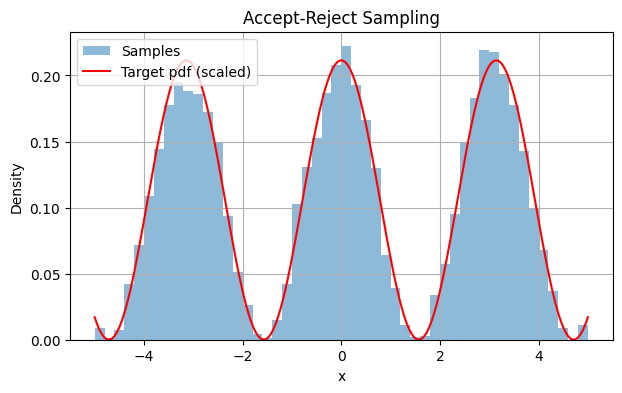

In [130]:
plotter(func_a, f_a_ymax)

Some issue: as y larger than ymax
Some issue: as y larger than ymax
Some issue: as y larger than ymax
Some issue: as y larger than ymax
Some issue: as y larger than ymax
Some issue: as y larger than ymax
Some issue: as y larger than ymax
Some issue: as y larger than ymax


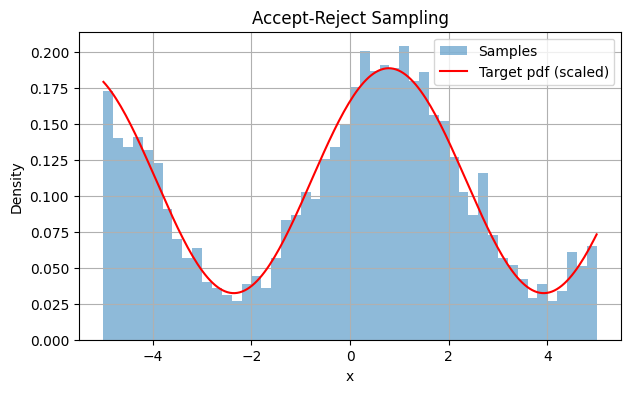

In [131]:
plotter(func_b, f_b_ymax)

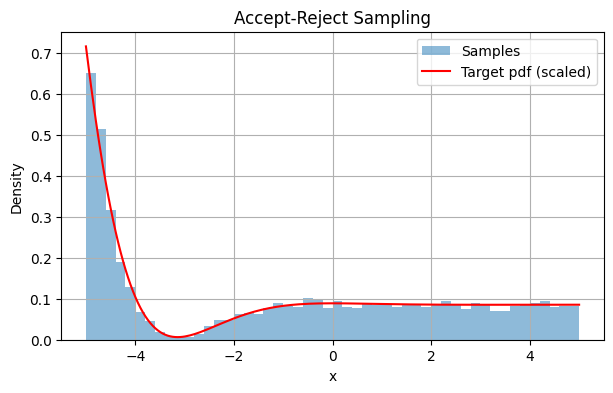

In [132]:
plotter(func_c, f_c_ymax)

Accept-reject generator in two-dimensions:
- Sample (x,y) from simple 2D dist
- Evaluate 2D target function
- Accept/reject in vertical dimension i.e., sample a height uniformly from [0,M], M = upper bound of target function -> accept if u <= f(x,y)

Accept-reject generator in two-dimensions:
- Sample x_hat = (x1, x2,..., xn) from n-dimensional dist
- Sample u ~ Uniform(0,M) where M bounds target density
- Accept if u <= f(x_hat)

Generation could be sped up by:
- Better proposal dist
    - Use a distribution q(x) that approximates the target function f(x) shape
    - Accept if u <= f(x) / (M*q(x)) where M is the bound on f(x)/q(x)
- Vectorisation and parallelisation
    - Generate many candidate samples at once
    - evaluate target func on all candidates simultaneously
    - Filter for accepted samples in one operation
- Early rejection
    - Use cheaper lower bound g(x) <= f(x)
    - Check u <= g(x); if false, reject without computing f(x)
    - Compute f(x) only if g(x) accepted

Generation efficiencies with 1D normal distribution (mu=0, sigma=1).

Plot of acceptance efficiency as a function of the generation range in terms of standard deviation.

In [ ]:
def standard_normal_pdf(x):
    return (1 / np.sqrt(2 * np.pi)) * np.exp(-x**2 / 2)

In [147]:
def acceptance_efficiency(func, x_range, ymax, n_trials):
    x_samples = np.random.uniform(x_range[0], x_range[1], n_trials)
    y_samples = np.random.uniform(0, ymax, n_trials)
    accepted = np.sum(y_samples <= func(x_samples))
    return accepted / n_trials

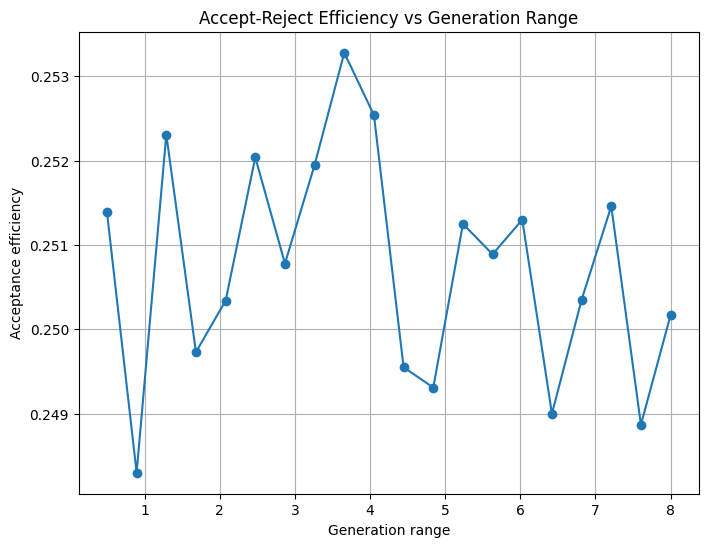

In [150]:
sigma_vals = np.linspace(0.5, 8, 20)
efficiencies = []

for val in sigma_vals:
    x_range = [-val, val]
    
    x_opt = np.linspace(*xrange, 1000)
    ymax = standard_normal_pdf(0)
    
    efficiency = acceptance_efficiency(standard_normal_pdf,
                                       xrange,
                                       ymax,
                                       n_trials=100000
                                       )
    efficiencies.append(efficiency)
    
plt.figure(figsize=(8,6))
plt.plot(sigma_vals, efficiencies, marker='o')
plt.title("Accept-Reject Efficiency vs Generation Range")
plt.xlabel("Generation range")
plt.ylabel("Acceptance efficiency")
plt.grid(True)
plt.show()
